# Day 0 · A Taste of the Course
*Measuring Manuscripts*

This notebook is a brief tour of what a two-week course in *computational philology* actually does. Rather than explain each method in full, which is the work of the course itself, we will simply run a few methods on real manuscripts and watch what they produce, from counting the words of a poem to teaching a machine to read handwriting.

None of this assumes any background in programming. Just be curious, dig into the parts you don't understand when you want to, trust the parts you don't investigate long enough to consider the results.

**Running the cells.** Each grey block below is a small program. Click one and press *Shift+Enter* to run it, then work downward in order. Two of the cells gather data over the network and take up to a minute. The rest return at once.

In [1]:
# A rite of passage
print("Hello, World!")

Hello, World!


# Part 1 · Text as data

The first thing a computer needs is something it can count. Our text is the opening of Chaucer's *Canterbury Tales*, written in the 1390s, and the task is to turn that handful of lines, which a reader experiences as poetry, into data a machine can tally.

In [2]:
text = "Whan that Aprille with his shoures soote,\nThe droghte of March hath perced to the roote,\nAnd bathed every veyne in swich licour\nOf which vertu engendred is the flour;\nWhan Zephirus eek with his swete breeth\nInspired hath in every holt and heeth\nThe tendre croppes, and the yonge sonne\nHath in the Ram his halfe cours y-ronne,\nAnd smale foweles maken melodye,\nThat slepen al the nyght with open ye,\nSo priketh hem Nature in hir corages,\nThanne longen folk to goon on pilgrimages,\nAnd palmeres for to seken straunge strondes,\nTo ferne halwes, kowthe in sondry londes;\nAnd specially, from every shires ende\nOf Engelond, to Caunterbury they wende,\nThe hooly blisful martir for to seke,\nThat hem hath holpen whan that they were seeke."
print(text)

Whan that Aprille with his shoures soote,
The droghte of March hath perced to the roote,
And bathed every veyne in swich licour
Of which vertu engendred is the flour;
Whan Zephirus eek with his swete breeth
Inspired hath in every holt and heeth
The tendre croppes, and the yonge sonne
Hath in the Ram his halfe cours y-ronne,
And smale foweles maken melodye,
That slepen al the nyght with open ye,
So priketh hem Nature in hir corages,
Thanne longen folk to goon on pilgrimages,
And palmeres for to seken straunge strondes,
To ferne halwes, kowthe in sondry londes;
And specially, from every shires ende
Of Engelond, to Caunterbury they wende,
The hooly blisful martir for to seke,
That hem hath holpen whan that they were seeke.


To a computer a text is at first only a string of characters, with no notion of where one word ends and the next begins. Splitting it on the spaces is the crudest possible remedy, and for English it is good enough to begin with. The running words it produces are *tokens*, and the distinct words among them are *types*.

In [3]:
words = text.replace('\n', ' ').split()
types = set(w.lower().strip('.,;:') for w in words)
print('Tokens (running words):', len(words))
print('Types (distinct words):', len(types))
print('Type/token ratio:', round(len(types) / len(words), 2))

Tokens (running words): 128
Types (distinct words): 88
Type/token ratio: 0.69


### Zipf's law

Counting the words of a short passage is unremarkable. Counting the words of the whole text is where something unexpected appears. If we rank every word from the most common to the least and plot rank against frequency on logarithmic axes, the points fall along a nearly straight line. A small handful of words carries most of the text, and a long tail of words occurs exactly once. We did not arrange this. It is a regularity that counting reveals, and it holds across languages and across centuries.

6,672 words, 1,790 distinct.


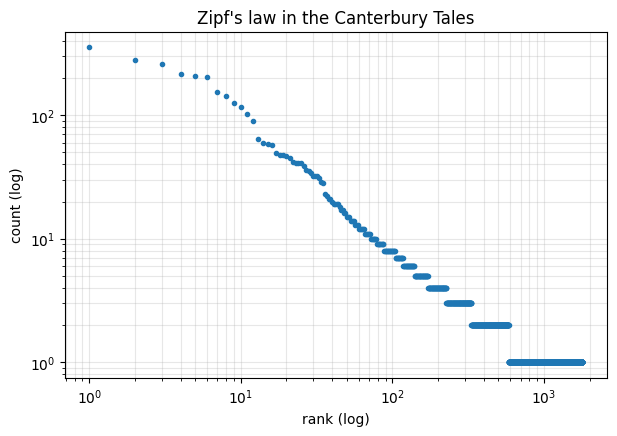

In [4]:
import urllib.request, numpy as np
import matplotlib.pyplot as plt
from collections import Counter

URL = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
       'refs/heads/main/Workbook/Day%201%E2%80%94Traditional%20Philology/Canterbury%20Tales.txt')
full = urllib.request.urlopen(URL).read().decode('utf-8')
tokens = [w.lower().strip('.,;:!?()"\'') for w in full.split()]
tokens = [w for w in tokens if w]
freq = Counter(tokens)
print(f'{len(tokens):,} words, {len(freq):,} distinct.')

values = [n for _, n in freq.most_common()]
ranks = np.arange(1, len(values) + 1)
plt.figure(figsize=(7, 4.5))
plt.loglog(ranks, values, marker='.', linestyle='none')
plt.xlabel('rank (log)'); plt.ylabel('count (log)')
plt.title("Zipf's law in the Canterbury Tales"); plt.grid(True, which='both', alpha=0.3)
plt.show()

### A concordance

A *concordance* gathers every occurrence of a chosen word together with the words around it, so that its uses can be compared at a glance. For most of the history of scholarship this was the labor of years, compiled by hand and printed in heavy volumes. Here it costs a fraction of a second.

In [5]:
STOP = set('the a an and or but of to in on at by for with as is was were be that this which who his '
           'her he she it they them him so then than do up out when their all from if no not there have '
           'has had would will shall may i you we us me my your our such some any every now yet also '
           'ye thou thee thy hath hir hem ne eke unto whan ther wel ful swich nas'.split())
keyword = next(w for w, _ in freq.most_common() if w not in STOP and len(w) > 3)

def kwic(word, width=4, limit=8):
    shown = 0
    for k, w in enumerate(tokens):
        if w == word:
            left  = ' '.join(tokens[max(0, k-width):k])
            right = ' '.join(tokens[k+1:k+1+width])
            print(f'{left:>34}  [ {word} ]  {right}')
            shown += 1
            if shown >= limit: break

print(f'Every occurrence of "{keyword}" in context:\n')
kwic(keyword)

Every occurrence of "well" in context:

           come into that hostelry  [ well ]  nine and twenty in
             stables were wide and  [ well ]  we weren eased at
                   no man farre as  [ well ]  in christendom as in
            picardie and borne him  [ well ]  as of so little
             sleeves long and wide  [ well ]  could he sit on
            coulde songes make and  [ well ]  indite joust and eke
                 and eke dance and  [ well ]  pourtray and write so
            he bare full thriftily  [ well ]  could he dress his


### The phrases a text repeats

If we count not single words but short runs of two and three consecutive words, the habitual phrases of a text rise to the surface on their own. In the pilgrim portraits of the *General Prologue*, the small formula *he was a* introduces one figure after another. We need not have known in advance that it was there for the counting to find it.

In [6]:
def ngrams(seq, n):
    return Counter(tuple(seq[i:i+n]) for i in range(len(seq)-n+1))

print('Most common trigrams:')
for gram, n in ngrams(tokens, 3).most_common(6):
    print(f'  {" ".join(gram):26} {n}')

content_bigrams = Counter((a, b) for a, b in zip(tokens, tokens[1:])
                          if a not in STOP and b not in STOP)
print('\nContent phrases (function words removed):')
for gram, n in content_bigrams.most_common(6):
    print(f'  {" ".join(gram):26} {n}')

Most common trigrams:
  he was a                   13
  well could he              11
  he had a                   7
  as is a                    6
  there was no               5
  there was a                5

Content phrases (function words removed):
  well could                 14
  full fair                  5
  full many                  5
  worthy man                 4
  full often                 3
  full well                  3


### One number for a whole text

*Shannon entropy* compresses an entire text to a single quantity: the average surprise of its next word, measured in bits. It is the idea behind file compression and behind every modern language model. A caution comes built in. If we shuffle the words into a random order and measure again, the number does not change at all, which tells us plainly what entropy can and cannot see. It is deaf to word order, and registers only how often each word occurs.

In [7]:
import math
def entropy(items):
    n = len(items)
    return -sum((c/n) * math.log2(c/n) for c in Counter(items).values())

import random
shuffled = tokens[:]; random.Random(0).shuffle(shuffled)
print('Word entropy:         ', round(entropy(tokens), 3), 'bits per word')
print('After shuffling words:', round(entropy(shuffled), 3), 'bits per word')
print('Same number. Word entropy says nothing about word order.')

Word entropy:          8.519 bits per word
After shuffling words: 8.519 bits per word
Same number. Word entropy says nothing about word order.


### Length and information

The lengths of words are not arbitrary either. Each word carries a measurable amount of *information*, its surprisal, written -log2 of its probability, which is precisely the quantity entropy averages over. Plotting that information against word length, we find the two rising together: the commonest words, *the* and *of* and *and*, carry almost no information and are correspondingly short, while the rarest words carry the most and run the longest. Why a language should arrange itself so economically is a genuine question, and one the full course takes a day to pursue.

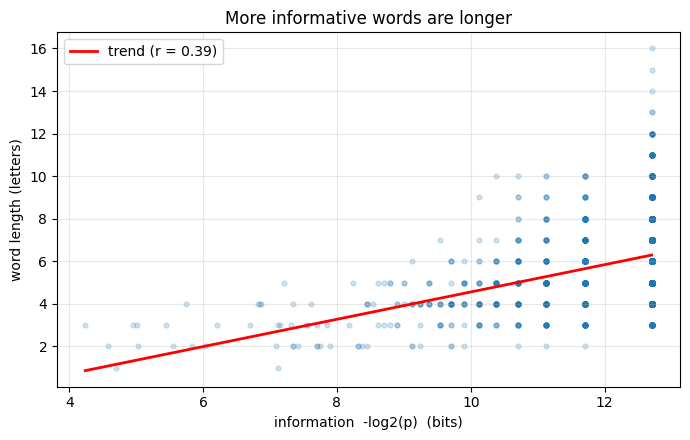

Word length vs information: r = 0.39  (rarer = more information = longer).


In [30]:
import numpy as np
words  = list(freq)
N      = sum(freq.values())
length = np.array([len(w) for w in words])
info   = np.array([-np.log2(freq[w] / N) for w in words])   # surprisal in bits: the term entropy averages
r = np.corrcoef(info, length)[0, 1]
b1, b0 = np.polyfit(info, length, 1)
xs = np.array([info.min(), info.max()])
plt.figure(figsize=(7, 4.5))
plt.scatter(info, length, alpha=0.2, s=12)
plt.plot(xs, b1*xs + b0, 'r-', lw=2, label=f'trend (r = {r:.2f})')
plt.xlabel('information  -log2(p)  (bits)'); plt.ylabel('word length (letters)')
plt.title('More informative words are longer'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Word length vs information: r = {r:.2f}  (rarer = more information = longer).')

# Part 2 · Weighing the witnesses

We almost never possess the original of an old text. The *Canterbury Tales* survive in roughly eighty handwritten copies, no two of them alike and none in Chaucer's own hand. Each copy is a *witness*, an imperfect testimony to what he wrote, and when the witnesses disagree the task of deciding what he most likely wrote falls to an editor.

When two copies of a line diverge, a computer can show us at once exactly where they part. In the couplet below, the rhyme with *londes* is what settles the matter: Chaucer wrote *strondes*, even though that is not the reading the majority of copies happen to carry.

In [9]:
import difflib
witness_1 = 'And palmeres for to seken straunge contrees'
witness_2 = 'And palmeres for to seken straunge strondes'
for d in difflib.ndiff(witness_1.split(), witness_2.split()):
    print(d)    # '-' only in copy 1, '+' only in copy 2, ' ' in both

  And
  palmeres
  for
  to
  seken
  straunge
- contrees
+ strondes


### Four witnesses, side by side

The same comparison scales. Here is the first line of the *General Prologue* as four scribes actually wrote it. Aligning them word by word makes their disagreements, most of them matters of spelling, immediately visible. What we do by hand for four copies a computer does for eighty in a single pass.

In [10]:
witnesses = {
 'Hengwrt':   'Whan that Aueryll wt his shoures soote',
 'Ellesmere': 'WHan that Aprill with hise shoures soote',
 'Harley':    'Whan that aprille with his schowres swoote',
 'Laud':      'WHan that Aprill wyth his schoures soote',
}
rows = {name: line.split() for name, line in witnesses.items()}
ncol = max(len(r) for r in rows.values())
print('   ' + '  '.join(f'{name:10}' for name in rows))
print('   ' + '  '.join('-'*10 for _ in rows))
for c in range(ncol):
    forms = [rows[name][c] if c < len(rows[name]) else '' for name in rows]
    mark = ' ' if len({f.lower() for f in forms}) == 1 else '*'   # * = scribes disagree
    print(f'{mark}  ' + '  '.join(f'{f:10}' for f in forms))

   Hengwrt     Ellesmere   Harley      Laud      
   ----------  ----------  ----------  ----------
   Whan        WHan        Whan        WHan      
   that        that        that        that      
*  Aueryll     Aprill      aprille     Aprill    
*  wt          with        with        wyth      
*  his         hise        his         his       
*  shoures     shoures     schowres    schoures  
*  soote       soote       swoote      soote     


# Part 3 · Script as data

We turn now from the words of a text to the shapes in which they are written. A letter, it turns out, is not a single shape but a range of them, since no two scribes form it in quite the same way, and a single scribe rarely does so twice. *Hieratic* is the cursive hand of ancient Egypt. Below is one sign, *G17*, the owl (𓅓), as it was drawn again and again within a single Middle Egyptian text.

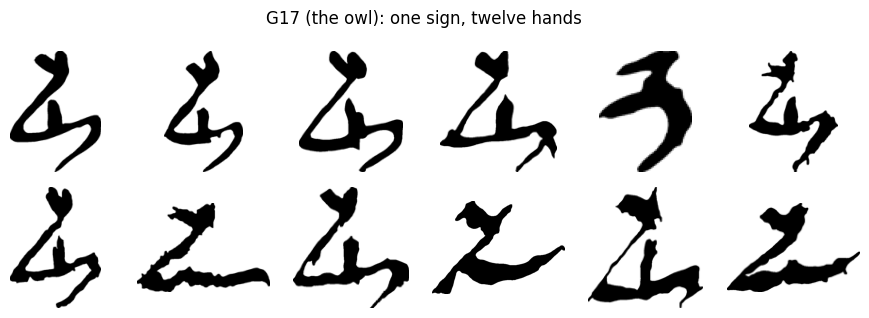

In [11]:
import io, csv, urllib.request
from PIL import Image
import matplotlib.pyplot as plt

ISUT = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
        'refs/heads/main/Workbook/Day%207%E2%80%94Visualization/Isut/')

def g17_crops(folder, n=12):
    csv_url = ISUT + folder + '/overlay_output/all_colored_signs.csv'
    rows = [r for r in csv.DictReader(io.StringIO(
                urllib.request.urlopen(csv_url).read().decode('utf-8')))
            if r['unicode_key'] == 'U+13153'][:n]      # U+13153 = Gardiner G17, the owl
    owls = []
    for r in rows:
        rel = r['image_path'].replace('texts/', '', 1)
        im  = Image.open(io.BytesIO(urllib.request.urlopen(ISUT + rel).read())).convert('RGBA')
        owls.append(Image.alpha_composite(Image.new('RGBA', im.size, (255,255,255,255)), im))
    return owls

owls = g17_crops('Shipwrecked', 12)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for ax, im in zip(axes.ravel(), owls):
    ax.imshow(im); ax.axis('off')
fig.suptitle('G17 (the owl): one sign, twelve hands')
plt.tight_layout(); plt.show()

### Teaching a machine to read handwriting

The problem of reading handwriting by machine is called *handwritten text recognition*, or HTR, and it is what allows photographs of manuscripts to become searchable text. The standard first example is not ancient at all but a collection of handwritten digits, seventy thousand of them, each recorded as a grid of twenty-eight by twenty-eight pixels.

In [12]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype(int)
rng = np.random.default_rng(0)
idx = rng.choice(len(X), 8000, replace=False)
X = X[idx] / 255.0
y = y[idx]
Xtr, Xte, ytr, yte = X[:6000], X[6000:], y[:6000], y[6000:]
print('Loaded', X.shape[0], 'digits.  Learning from', len(Xtr), ', testing on', len(Xte))

Loaded 8000 digits.  Learning from 6000 , testing on 2000


Each digit is therefore a list of 784 numbers, far more than we can hold in the mind or draw on a page. *Principal component analysis* finds the two directions along which the digits vary most and projects them onto a flat chart. Without ever being told which digit is which, the method already separates them into ten distinct clouds.

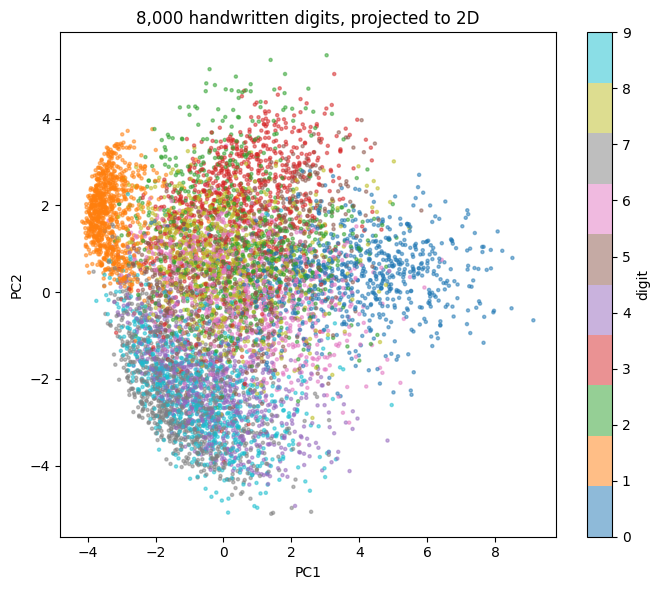

In [13]:
coords = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(7, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=y, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(sc, ticks=range(10), label='digit')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('8,000 handwritten digits, projected to 2D')
plt.tight_layout(); plt.show()

We now train a simple classifier on six thousand of the digits and ask it to read two thousand more that it has never encountered.

In [14]:
pca50 = PCA(n_components=50).fit(Xtr)
knn = KNeighborsClassifier(n_neighbors=10).fit(pca50.transform(Xtr), ytr)
proba = knn.predict_proba(pca50.transform(Xte))
pred = proba.argmax(1)
confidence = proba.max(1)
print(f'It read {(pred == yte).sum()} of {len(yte)} correctly: {accuracy_score(yte, pred):.1%} accuracy.')

It read 1887 of 2000 correctly: 94.3% accuracy.


Its successes are less instructive than its failures. The digits below are the ones it judged least confidently, and many of them are forms a person would also hesitate over. The same kinds of error reappear, in more consequential form, when such methods are turned on real scribal hands.

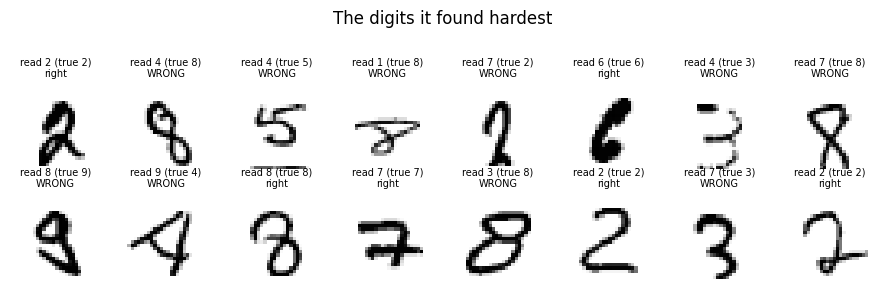

Most common confusion: a real 4 read as a 9 (11 times).


In [15]:
order = np.argsort(confidence)        # least confident first
fig, axes = plt.subplots(2, 8, figsize=(9, 2.8))
for ax, i in zip(axes.ravel(), order[:16]):
    ax.imshow(Xte[i].reshape(28, 28), cmap='gray_r')
    mark = 'right' if pred[i] == yte[i] else 'WRONG'
    ax.set_title(f'read {pred[i]} (true {yte[i]})\n{mark}', fontsize=7)
    ax.axis('off')
fig.suptitle('The digits it found hardest', y=1.04)
plt.tight_layout(); plt.show()

cm = confusion_matrix(yte, pred); off = cm.copy(); np.fill_diagonal(off, 0)
a, b = np.unravel_index(off.argmax(), off.shape)
print(f'Most common confusion: a real {a} read as a {b} ({off[a, b]} times).')

### From digits to scribes

The procedure that sorted the digits applies without change to the owls. We turn every drawing of *G17* from two Middle Egyptian texts into a row of numbers and project them down to two dimensions. The shapes separate into a few recurring forms, and one of those forms appears almost exclusively in a single text, the *Shipwrecked Sailor*. That is a finding about scribal habit, and a reproduction of a published result. Gathering the images takes up to a minute.

fetching Peasant B1 ...
fetching Shipwrecked ...


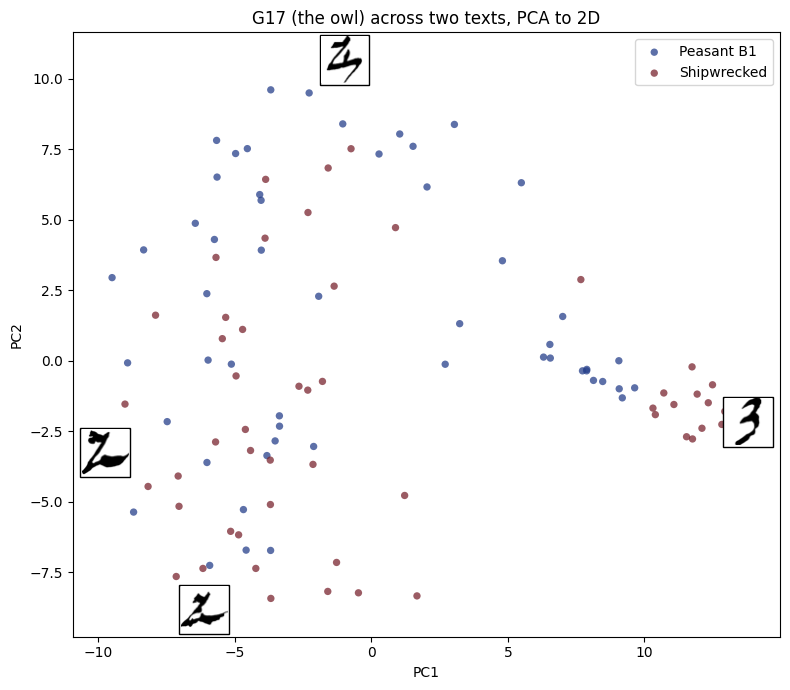

In [16]:
from sklearn.cluster import KMeans
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

FOLDER = {'Peasant B1': 'PeasantB1', 'Shipwrecked': 'Shipwrecked'}
CAP = 55     # a sample of each text keeps the live demo fast

def load_sign(folder, cap=CAP, size=48):
    rows = [r for r in csv.DictReader(io.StringIO(
                urllib.request.urlopen(ISUT + folder + '/overlay_output/all_colored_signs.csv').read().decode('utf-8')))
            if r['unicode_key'] == 'U+13153'][:cap]
    vecs, crops = [], []
    for r in rows:
        rel  = r['image_path'].replace('texts/', '', 1)
        im   = Image.open(io.BytesIO(urllib.request.urlopen(ISUT + rel).read())).convert('RGBA')
        gray = Image.alpha_composite(Image.new('RGBA', im.size, (255,255,255,255)), im).convert('L')
        w, h = gray.size; s = max(w, h)
        sq = Image.new('L', (s, s), 255); sq.paste(gray, ((s-w)//2, (s-h)//2))
        small = sq.resize((size, size))
        crops.append(small); vecs.append(255.0 - np.asarray(small, float))
    return np.array([v.ravel() for v in vecs]) / 255.0, crops

Xh, labels, crops = [], [], []
for name, folder in FOLDER.items():
    print('fetching', name, '...')
    V, C = load_sign(folder)
    Xh.append(V); crops += C; labels += [name] * len(V)
Xh = np.vstack(Xh); labels = np.array(labels)

Z = PCA(n_components=2).fit_transform(Xh - Xh.mean(0))
color = {'Shipwrecked': '#7a2630', 'Peasant B1': '#27408b'}
fig, ax = plt.subplots(figsize=(8, 7))
for name in FOLDER:
    m = labels == name
    ax.scatter(Z[m,0], Z[m,1], c=color[name], s=28, alpha=0.75, edgecolors='none', label=name)
for i in {Z[:,0].argmin(), Z[:,0].argmax(), Z[:,1].argmin(), Z[:,1].argmax()}:
    ax.add_artist(AnnotationBbox(OffsetImage(np.asarray(crops[i]), cmap='gray', zoom=0.7),
                                 (Z[i,0], Z[i,1]), frameon=True, pad=0.1))
ax.legend(); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('G17 (the owl) across two texts, PCA to 2D')
plt.tight_layout(); plt.show()

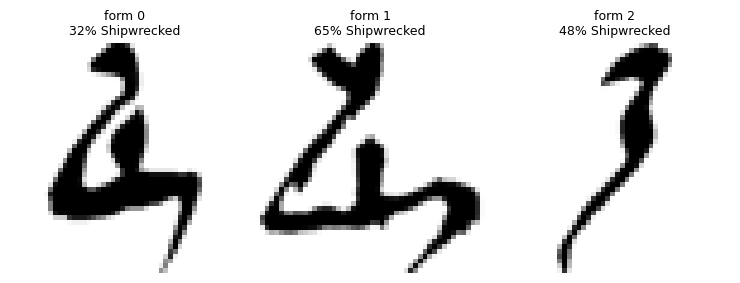

In [17]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z)
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.8))
for c in range(3):
    m = km.labels_ == c
    ship = int(((labels == 'Shipwrecked') & m).sum()); total = int(m.sum())
    medoid = np.where(m)[0][np.argmin(((Z[m] - Z[m].mean(0))**2).sum(1))]
    axes[c].imshow(crops[medoid], cmap='gray'); axes[c].axis('off')
    axes[c].set_title(f'form {c}\n{ship/total:.0%} Shipwrecked', fontsize=9)
plt.tight_layout(); plt.show()

# Part 4 · Even the sound

We have no recording of Chaucer's voice, and none of Coptic, which has had no native speakers for centuries. Before we try to measure a sound we cannot hear, then, it is worth building one we can. A vowel is a buzz produced by the vocal folds and shaped by the resonances of the mouth. If we generate a plain buzz and impose on it the right resonances, the *formants*, the result is a recognizable vowel. The cell below assembles one from nothing but a few numbers.

In [18]:
import numpy as np
from scipy.signal import lfilter
from IPython.display import Audio, display
fs = 16000   # sampling rate, Hz

def synth_vowel(formants, f0=120, dur=0.6, fs=fs):
    """A buzz at pitch f0, shaped by one resonator per formant (freq_Hz, bandwidth_Hz)."""
    n = int(dur * fs)
    source = np.zeros(n); source[::int(fs / f0)] = 1.0          # glottal pulses
    out = source.copy()
    for freq, bw in formants:
        r = np.exp(-np.pi * bw / fs); theta = 2 * np.pi * freq / fs
        out = lfilter([1 - r], [1, -2*r*np.cos(theta), r*r], out)
    return out / np.max(np.abs(out))

a = synth_vowel([(730, 70), (1090, 70), (2440, 90), (3500, 120), (4500, 150)])   # /a/ as in father
print('/a/ as in father:')
Audio(a, rate=fs)

/a/ as in father:


The five vowels differ from one another in nothing but their formant frequencies. The cell synthesizes each in turn from its own short list of numbers, so that the difference between *beet* and *boot* becomes a difference you can both see and hear.

In [19]:
VOWELS = {
    'i (beet)':   [270, 2290, 3010, 3500, 4500],
    'e (bait)':   [530, 1840, 2480, 3500, 4500],
    'a (father)': [730, 1090, 2440, 3500, 4500],
    'o (bought)': [570,  840, 2410, 3500, 4500],
    'u (boot)':   [300,  870, 2240, 3500, 4500],
}
for name, F in VOWELS.items():
    print(name)
    display(Audio(synth_vowel([(f, 80) for f in F]), rate=fs))

i (beet)


e (bait)


a (father)


o (bought)


u (boot)


Holding the first formant fixed and raising only the second, we can listen to a single vowel travel from the back of the mouth to the front. One number governs the entire front-to-back axis of speech.

In [20]:
F1 = 500
for f2 in [900, 1200, 1500, 1800, 2100, 2400]:      # back -> front
    print(f'F2 = {f2} Hz')
    display(Audio(synth_vowel([(F1, 80), (f2, 90), (2800, 120)]), rate=fs))

F2 = 900 Hz


F2 = 1200 Hz


F2 = 1500 Hz


F2 = 1800 Hz


F2 = 2100 Hz


F2 = 2400 Hz


Plotting each vowel by its first two formants yields the *vowel space*, in effect a map of the mouth: the first formant tracks how open it is, and the second how far forward the tongue lies. This same chart is where the analysis of real recordings begins.

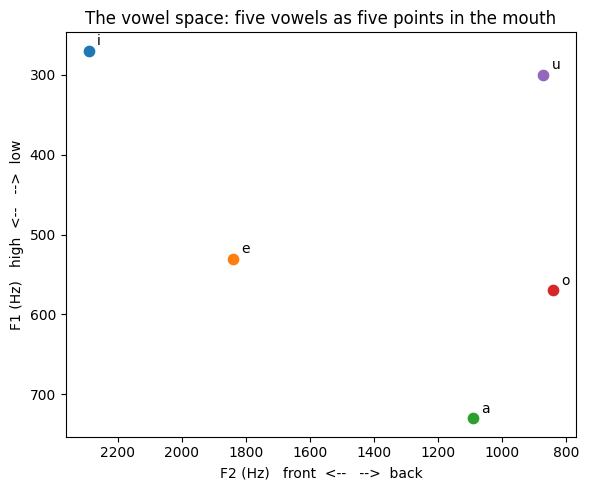

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 5))
for name, F in VOWELS.items():
    ax.scatter(F[1], F[0], s=55)
    ax.annotate(name.split()[0], (F[1], F[0]), xytext=(6, 4), textcoords='offset points')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('F2 (Hz)   front  <--   -->  back'); ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
ax.set_title('The vowel space: five vowels as five points in the mouth')
plt.tight_layout(); plt.show()

These positions are not fixed for all time. In the centuries after Chaucer the long vowels of English migrated around this very space, in the chain of changes known as the *Great Vowel Shift*, which is the reason a number of his rhymes no longer rhyme for us. The arrows trace that movement.

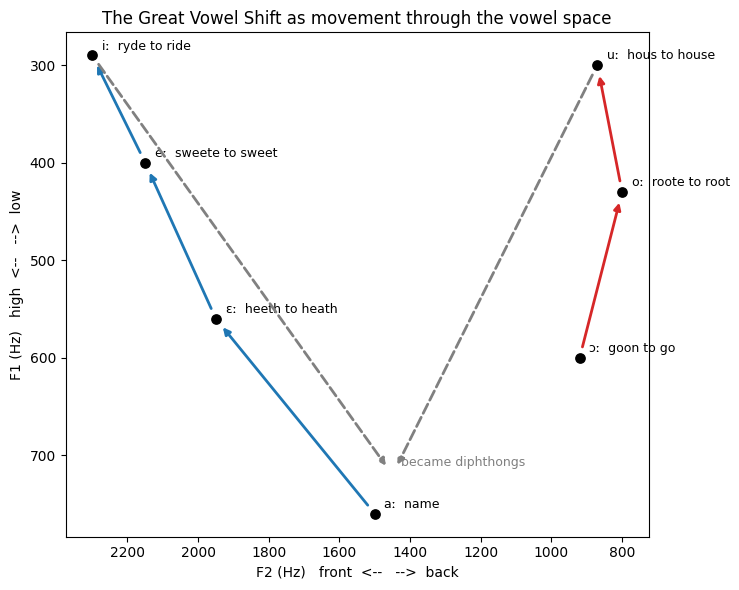

In [22]:
chain_front = ['aː', 'ɛː', 'eː', 'iː']
chain_back  = ['ɔː', 'oː', 'uː']
pos = {'iː':(2300,290),'eː':(2150,400),'ɛː':(1950,560),'aː':(1500,760),
       'uː':(870,300),'oː':(800,430),'ɔː':(920,600)}
word = {'iː':'ryde to ride','eː':'sweete to sweet','ɛː':'heeth to heath',
        'aː':'name','uː':'hous to house','oː':'roote to root','ɔː':'goon to go'}
fig, ax = plt.subplots(figsize=(7.5, 6))
for v, (f2, f1) in pos.items():
    ax.scatter(f2, f1, s=45, color='black', zorder=3)
    ax.annotate(f'{v}  {word[v]}', (f2, f1), xytext=(7, 4), textcoords='offset points', fontsize=9)
def chain(seq, color):
    for a, b in zip(seq, seq[1:]):
        ax.annotate('', xy=pos[b], xytext=pos[a],
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=2, shrinkA=8, shrinkB=8))
chain(chain_front, 'C0'); chain(chain_back, 'C3')
for v in ['iː', 'uː']:
    ax.annotate('', xy=(1450, 720), xytext=pos[v],
                arrowprops=dict(arrowstyle='-|>', color='gray', lw=2, ls='--', shrinkA=8, shrinkB=8))
ax.annotate('became diphthongs', (1450, 720), xytext=(6, 6), textcoords='offset points',
            fontsize=9, color='gray')
ax.set_xlabel('F2 (Hz)   front  <--   -->  back'); ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_title('The Great Vowel Shift as movement through the vowel space')
plt.tight_layout(); plt.show()

### Reconstructing the vowels of Coptic

The vowels so far have been either synthetic or living. The last are neither. How the vowels of Coptic sounded has been disputed for over a century, with a letter such as eta (ⲏ) placed at nearly every position on the chart. Measuring the formants of recorded Coptic words, however, sets each letter at a definite place, and the synthesizer can then rebuild each vowel from those measurements, letting us hear, with all due caution, a language no one has spoken in a thousand years.

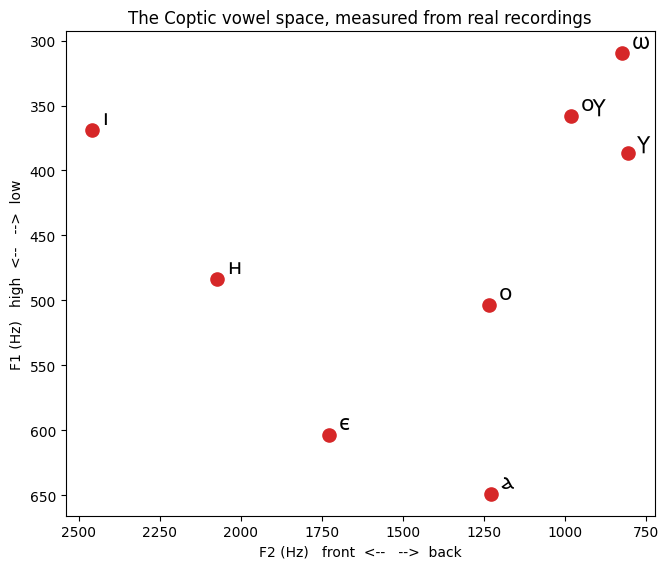

ⲓ (iota):  F1 = 369 Hz,  F2 = 2459 Hz


ⲏ (eta):  F1 = 483 Hz,  F2 = 2074 Hz


ⲉ (epsilon):  F1 = 603 Hz,  F2 = 1729 Hz


ⲁ (alpha):  F1 = 649 Hz,  F2 = 1229 Hz


ⲟ (omicron):  F1 = 503 Hz,  F2 = 1235 Hz


ⲩ (upsilon):  F1 = 386 Hz,  F2 = 806 Hz


ⲱ (omega):  F1 = 310 Hz,  F2 = 823 Hz


ⲟⲩ (ou):  F1 = 358 Hz,  F2 = 982 Hz


In [23]:
# Measure real Coptic vowel recordings from the repo, place them, and hear them rebuilt.
try:
    import parselmouth
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'praat-parselmouth']); import parselmouth
import urllib.request, tempfile, os
from IPython.display import Audio, display
from matplotlib import font_manager
_cop_ttf = '/tmp/NotoSansCoptic-Regular.ttf'
if not os.path.exists(_cop_ttf):
    urllib.request.urlretrieve('https://github.com/google/fonts/raw/main/ofl/notosanscoptic/NotoSansCoptic-Regular.ttf', _cop_ttf)
font_manager.fontManager.addfont(_cop_ttf)
COP_FONT = font_manager.FontProperties(fname=_cop_ttf)   # so the vowel letters render as ⲁ ⲉ ⲏ ⲓ ⲟ ⲩ ⲱ

CB = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
      'refs/heads/main/Workbook/Day%205%E2%80%94Sound%20as%20Data/coptic_audio/')
VOWELS = {'iota':('I','ⲓ'), 'eta':('H','ⲏ'), 'epsilon':('ε','ⲉ'), 'alpha':('α','ⲁ'),
          'omicron':('O','ⲟ'), 'upsilon':('Y','ⲩ'), 'omega':('ω','ⲱ'), 'ou':('OY','ⲟⲩ')}

def measure(path, maxf=5500):
    snd = parselmouth.Sound(path)
    if snd.n_channels > 1: snd = snd.convert_to_mono()
    fm = snd.to_formant_burg(maximum_formant=maxf)
    d = snd.get_total_duration(); ts = np.linspace(0.3*d, 0.7*d, 15)
    return (np.nanmean([fm.get_value_at_time(1,t) for t in ts]),
            np.nanmean([fm.get_value_at_time(2,t) for t in ts]))

cent = {}
for v in VOWELS:
    pts = []
    for k in range(1, 6):                       # up to five clips per vowel, from the repo on GitHub
        try:
            raw = urllib.request.urlopen(CB + f'{v}_{k}.wav').read()
            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tf:
                tf.write(raw); p = tf.name
            pts.append(measure(p)); os.remove(p)
        except Exception:
            pass
    if pts:
        cent[v] = np.mean(pts, 0)

if cent:
    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    for v, (f1, f2) in cent.items():
        ax.scatter(f2, f1, s=90, color='C3')
        ax.annotate(VOWELS[v][1], (f2, f1), xytext=(7, 4), textcoords='offset points', fontsize=16, fontproperties=COP_FONT)
    ax.invert_xaxis(); ax.invert_yaxis()
    ax.set_xlabel('F2 (Hz)   front  <--   -->  back'); ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
    ax.set_title('The Coptic vowel space, measured from real recordings')
    plt.tight_layout(); plt.show()
    for v, (f1, f2) in cent.items():
        print(f'{VOWELS[v][1]} ({v}):  F1 = {f1:.0f} Hz,  F2 = {f2:.0f} Hz')
        display(Audio(synth_vowel([(f1,80),(f2,90),(2800,120),(3500,150),(4500,180)]), rate=fs))
else:
    print('Add the Coptic vowel clips under Day 5 / coptic_audio/ and push, to hear and plot them here.')

# What we have seen

In the space of an hour a poem became a set of counts in which a hidden regularity appeared, a concordance assembled itself, four scribes were aligned, a machine learned to read handwriting, an Egyptian sign resolved into distinct forms, and a dead language yielded up its vowels. Each of these is only a glimpse of methods that require real care to use well, and yet none of it lies out of reach.

It bears repeating that none of this replaces the reading of old texts. The numbers do not hand us conclusions. They offer clues, pointing to relationships that were difficult to see and sending us back to the text better equipped to ask what they mean.